# EduShield â€” Model Machine Learning
## Prediksi Risiko Perundungan Siswa

Dataset: GSHS (Global School-based Student Health Survey) â€” WHO/CDC
Model: Random Forest Classifier

**Tujuan:** Memprediksi apakah siswa mengalami perundungan di lingkungan sekolah berdasarkan faktor-faktor risiko.

## 1. Import Pustaka

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, accuracy_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')
print('Pustaka berhasil diimpor')

Pustaka berhasil diimpor


## 2. Load Dataset

In [10]:
df = pd.read_csv('Bullying_2018.csv', delimiter=';')

print(f'Jumlah baris: {df.shape[0]}')
print(f'Jumlah kolom: {df.shape[1]}')
print(f'\nNama kolom:\n{list(df.columns)}')

Jumlah baris: 56981
Jumlah kolom: 18

Nama kolom:
['record', 'Bullied_on_school_property_in_past_12_months', 'Bullied_not_on_school_property_in_past_12_months', 'Cyber_bullied_in_past_12_months', 'Custom_Age', 'Sex', 'Physically_attacked', 'Physical_fighting', 'Felt_lonely', 'Close_friends', 'Miss_school_no_permission', 'Other_students_kind_and_helpful', 'Parents_understand_problems', 'Most_of_the_time_or_always_felt_lonely', 'Missed_classes_or_school_without_permission', 'Were_underweight', 'Were_overweight', 'Were_obese']


## 3. Eksplorasi Data Awal

In [11]:
df.head(10)

,record,Bullied_on_school_property_in_past_12_months,Bullied_not_on_school_property_in_past_12_months,Cyber_bullied_in_past_12_months,Custom_Age,Sex,Physically_attacked,Physical_fighting,Felt_lonely,Close_friends,Miss_school_no_permission,Other_students_kind_and_helpful,Parents_understand_problems,Most_of_the_time_or_always_felt_lonely,Missed_classes_or_school_without_permission,Were_underweight,Were_overweight,Were_obese
0,1,Yes,Yes,,13 years old,Female,0 times,0 times,Always,2,10 or more days,Never,Always,Yes,Yes,,,
1,2,No,No,No,13 years old,Female,0 times,0 times,Never,3 or more,0 days,Sometimes,Always,No,No,,,
2,3,No,No,No,14 years old,Male,0 times,0 times,Never,3 or more,0 days,Sometimes,Always,No,No,No,No,No
3,4,No,No,No,16 years old,Male,0 times,2 or 3 times,Never,3 or more,0 days,Sometimes,,No,No,No,No,No
4,5,No,No,No,13 years old,Female,0 times,0 times,Rarely,3 or more,0 days,Most of the time,Most of the time,No,No,,,
5,6,No,No,No,13 years old,Male,0 times,1 time,Never,3 or more,0 days,Most of the time,Always,No,No,No,No,No
6,7,No,No,No,14 years old,Female,1 time,0 times,Sometimes,3 or more,0 days,Most of the time,Always,No,No,,,
7,8,No,No,No,12 years old,Female,0 times,0 times,Rarely,3 or more,0 days,Most of the time,Never,No,No,,,
8,9,No,No,No,13 years old,Male,1 time,2 or 3 times,Never,3 or more,6 to 9 days,Most of the time,Most of the time,No,Yes,,,
9,10,Yes,No,No,14 years old,Female,0 times,0 times,Always,0,0 days,Sometimes,Never,Yes,No,,,


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56981 entries, 0 to 56980
Data columns (total 18 columns):
 #   Column                                            Non-Null Count  Dtype 
---  ------                                            --------------  ----- 
 0   record                                            56981 non-null  int64 
 1   Bullied_on_school_property_in_past_12_months      56981 non-null  object
 2   Bullied_not_on_school_property_in_past_12_months  56981 non-null  object
 3   Cyber_bullied_in_past_12_months                   56981 non-null  object
 4   Custom_Age                                        56981 non-null  object
 5   Sex                                               56981 non-null  object
 6   Physically_attacked                               56981 non-null  object
 7   Physical_fighting                                 56981 non-null  object
 8   Felt_lonely                                       56981 non-null  object
 9   Close_friends               

In [13]:
# Statistik deskriptif untuk kolom kategorikal
for col in df.columns:
    if col != 'record':
        print(f'\n=== {col} ===')
        print(df[col].value_counts(dropna=False).head(10))


=== Bullied_on_school_property_in_past_12_months ===
Bullied_on_school_property_in_past_12_months
No     43839
Yes    11903
        1239
Name: count, dtype: int64

=== Bullied_not_on_school_property_in_past_12_months ===
Bullied_not_on_school_property_in_past_12_months
No     44263
Yes    12229
         489
Name: count, dtype: int64

=== Cyber_bullied_in_past_12_months ===
Cyber_bullied_in_past_12_months
No     44213
Yes    12197
         571
Name: count, dtype: int64

=== Custom_Age ===
Custom_Age
14 years old               12946
15 years old               12812
16 years old               11738
13 years old               10574
17 years old                8227
18 years old or older        383
12 years old                 145
                             108
11 years old or younger       48
Name: count, dtype: int64

=== Sex ===
Sex
Female    29362
Male      27083
            536
Name: count, dtype: int64

=== Physically_attacked ===
Physically_attacked
0 times             46997
1 time

## 4. Preprocessing â€” Target Variable

In [14]:
# Target: apakah siswa di-bully di lingkungan sekolah
target_col = 'Bullied_on_school_property_in_past_12_months'

df[target_col] = df[target_col].fillna('No').str.strip()
df[target_col] = df[target_col].apply(lambda x: 'Yes' if x in ['Yes', 'yes', '1'] else 'No')

print('Distribusi target:')
print(df[target_col].value_counts())
print(f'\nProporsi:\n{df[target_col].value_counts(normalize=True)}')

Distribusi target:
Bullied_on_school_property_in_past_12_months
No     45078
Yes    11903
Name: count, dtype: int64

Proporsi:
Bullied_on_school_property_in_past_12_months
No     0.791106
Yes    0.208894
Name: proportion, dtype: float64


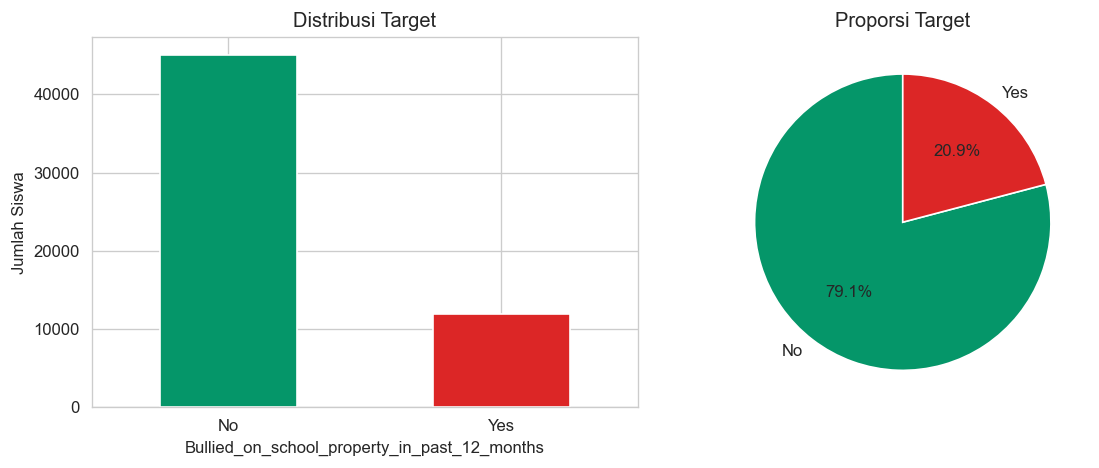

In [15]:
# Visualisasi distribusi target
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df[target_col].value_counts().plot(kind='bar', ax=axes[0], color=['#059669', '#dc2626'])
axes[0].set_title('Distribusi Target')
axes[0].set_ylabel('Jumlah Siswa')
axes[0].tick_params(axis='x', rotation=0)

wedges, texts, autotexts = axes[1].pie(
    df[target_col].value_counts(), labels=df[target_col].value_counts().index,
    autopct='%1.1f%%', colors=['#059669', '#dc2626'], startangle=90
)
axes[1].set_title('Proporsi Target')

plt.tight_layout()
plt.show()

**Observasi:** Dataset tidak seimbang (imbalanced). Siswa yang mengalami perundungan (*Yes*) jauh lebih sedikit.  
Model akan menggunakan `class_weight='balanced'` untuk menangani ini.

## 5. Preprocessing â€” Fitur Kategorikal

In [16]:
categorical_cols = [
    'Bullied_not_on_school_property_in_past_12_months',
    'Cyber_bullied_in_past_12_months',
    'Custom_Age', 'Sex', 'Physically_attacked', 'Physical_fighting',
    'Felt_lonely', 'Close_friends', 'Miss_school_no_permission',
    'Other_students_kind_and_helpful', 'Parents_understand_problems',
    'Most_of_the_time_or_always_felt_lonely',
    'Missed_classes_or_school_without_permission',
    'Were_underweight', 'Were_overweight', 'Were_obese'
]

# Pastikan semua kolom ada di dataset
existing_features = [c for c in categorical_cols if c in df.columns]
missing = [c for c in categorical_cols if c not in df.columns]
print(f'Fitur digunakan: {len(existing_features)}')
print('Fitur tidak ditemukan: ' + str(missing if missing else 'Semua ada'))

Fitur digunakan: 16
Fitur tidak ditemukan: Semua ada


In [17]:
label_encoders = {}

for col in existing_features:
    le = LabelEncoder()
    df[col] = df[col].fillna('Unknown')
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    
# Encode target
le_target = LabelEncoder()
df[target_col] = le_target.fit_transform(df[target_col].astype(str))
label_encoders[target_col] = le_target

print(f'Target classes: {le_target.classes_}')
print('Label encoding selesai')

Target classes: ['No' 'Yes']
Label encoding selesai


## 6. Split Data: Train / Test

In [18]:
feature_cols = existing_features
X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape[0]} ({X_train.shape[0]/len(df)*100:.1f}%)')
print(f'Test size:  {X_test.shape[0]} ({X_test.shape[0]/len(df)*100:.1f}%)')
print(f'\nDistribusi train: {np.bincount(y_train)}')
print(f'Distribusi test:  {np.bincount(y_test)}')

Train size: 45584 (80.0%)
Test size:  11397 (20.0%)

Distribusi train: [36062  9522]
Distribusi test:  [9016 2381]


## 7. Training â€” Random Forest Classifier

In [19]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)
print('Model berhasil dilatih!')

Model berhasil dilatih!


## 8. Evaluasi Model

In [20]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)

n_classes = len(np.unique(y))
if n_classes == 2:
    roc_auc = roc_auc_score(y_test, y_proba[:, 1])
else:
    roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr')

print(f'Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'ROC-AUC:   {roc_auc:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

Accuracy:  0.7658 (76.58%)
ROC-AUC:   0.7705

Classification Report:
              precision    recall  f1-score   support

          No       0.88      0.81      0.85      9016
         Yes       0.45      0.60      0.52      2381

    accuracy                           0.77     11397
   macro avg       0.67      0.70      0.68     11397
weighted avg       0.79      0.77      0.78     11397



### 8.1 Confusion Matrix

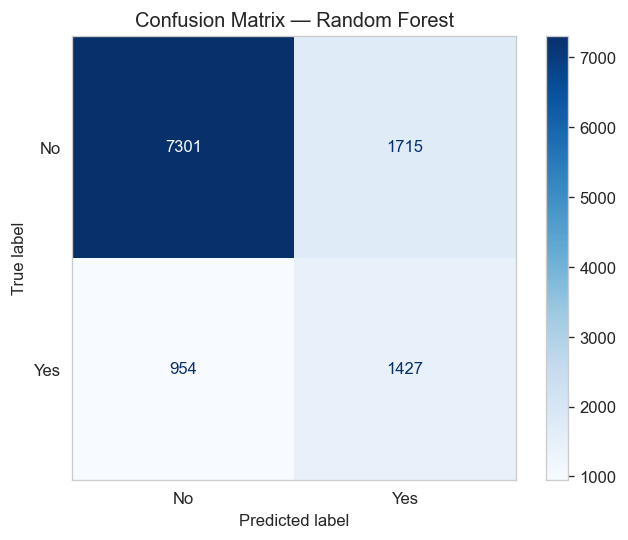

True Negatives:  7301
False Positives: 1715
False Negatives: 954
True Positives:  1427

Precision (Yes): 0.4542
Recall (Yes):    0.5993
F1-Score (Yes):  0.5167


In [21]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix â€” Random Forest')
plt.grid(False)
plt.show()

# Hitung metrik manual
tn, fp, fn, tp = cm.ravel()
print(f'True Negatives:  {tn}')
print(f'False Positives: {fp}')
print(f'False Negatives: {fn}')
print(f'True Positives:  {tp}')
print(f'\nPrecision (Yes): {tp/(tp+fp):.4f}')
print(f'Recall (Yes):    {tp/(tp+fn):.4f}')
print(f'F1-Score (Yes):  {2*tp/(2*tp+fp+fn):.4f}')

### 8.2 ROC Curve

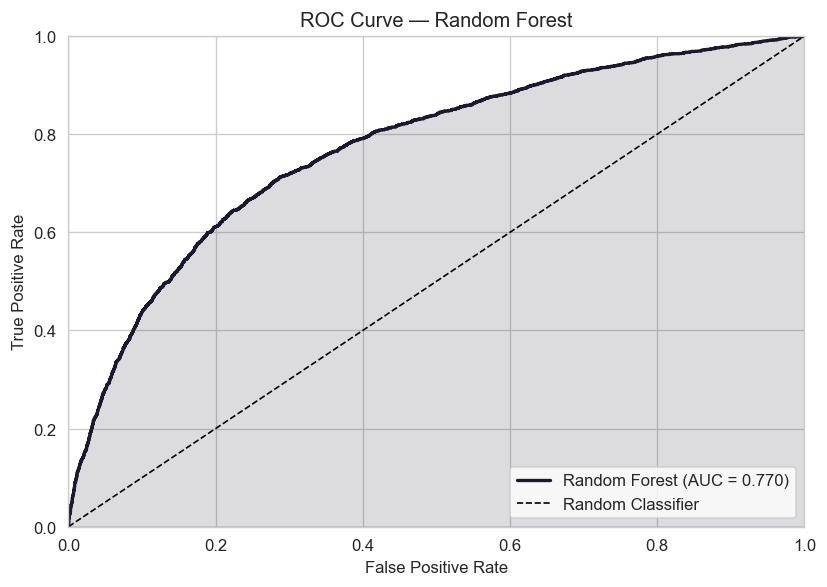

In [22]:
if n_classes == 2:
    fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1])
    
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(fpr, tpr, color='#1a1a2e', lw=2, label=f'Random Forest (AUC = {roc_auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
    ax.fill_between(fpr, tpr, alpha=0.15, color='#1a1a2e')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curve â€” Random Forest')
    ax.legend(loc='lower right')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    plt.tight_layout()
    plt.show()

### 8.3 Feature Importance

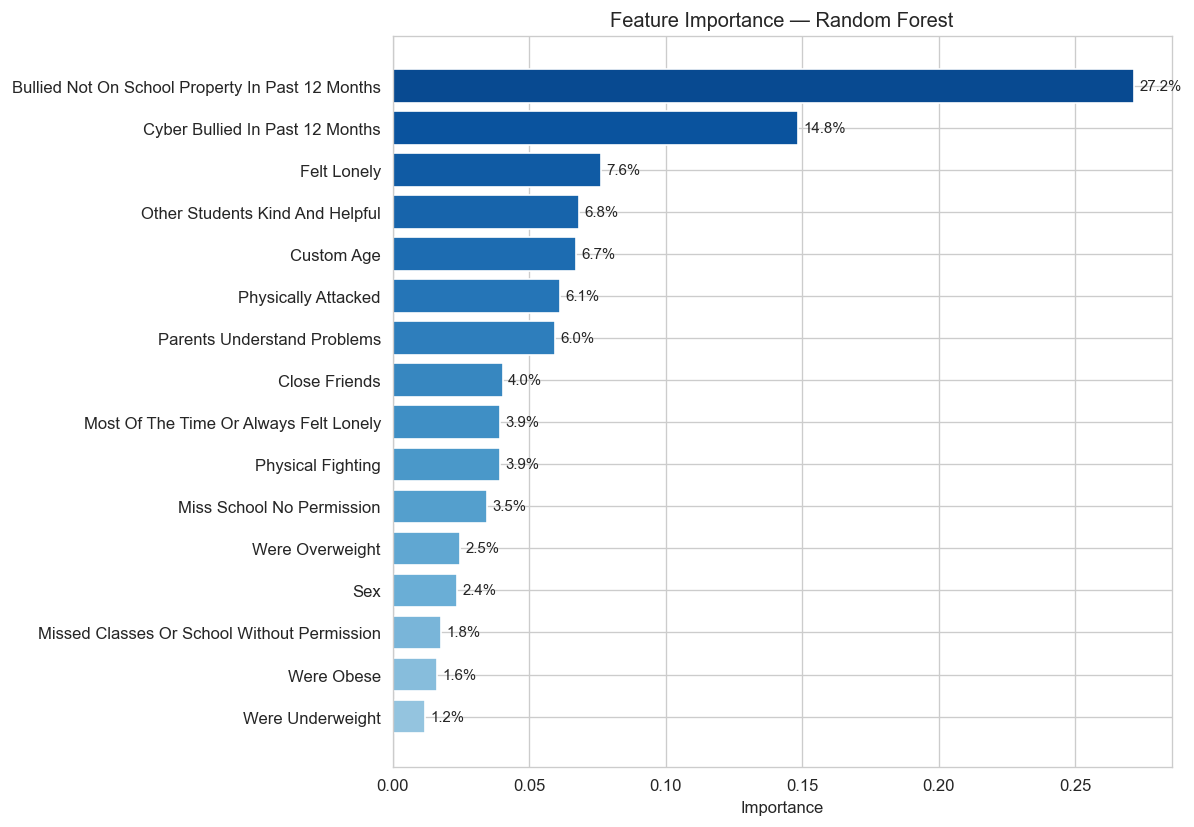

In [23]:
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(feature_importance)))
ax.barh(range(len(feature_importance)), feature_importance['importance'].values, color=colors)
ax.set_yticks(range(len(feature_importance)))
ax.set_yticklabels([f.replace('_', ' ').title() for f in feature_importance['feature']])
ax.set_xlabel('Importance')
ax.set_title('Feature Importance â€” Random Forest')

for i, v in enumerate(feature_importance['importance'].values):
    ax.text(v + 0.002, i, f'{v*100:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [24]:
# Top 10
print('Top 10 Fitur Paling Penting:')
print(feature_importance.sort_values('importance', ascending=False).head(10).to_string(index=False))

Top 10 Fitur Paling Penting:
                                         feature  importance
Bullied_not_on_school_property_in_past_12_months    0.271597
                 Cyber_bullied_in_past_12_months    0.148306
                                     Felt_lonely    0.076144
                 Other_students_kind_and_helpful    0.068248
                                      Custom_Age    0.067002
                             Physically_attacked    0.061267
                     Parents_understand_problems    0.059502
                                   Close_friends    0.040257
          Most_of_the_time_or_always_felt_lonely    0.039305
                               Physical_fighting    0.039285


**Interpretasi:**  
Fitur dengan importance tertinggi adalah indikator langsung dari pengalaman perundungan sebelumnya, yang merupakan prediktor terkuat.  
Faktor sosial-emosional seperti kesepian dan dukungan orang tua juga berkontribusi signifikan.

## 9. Cross-Validation

In [25]:
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(f'Cross-Validation Accuracy Scores: {cv_scores}')
print(f'Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})')

cv_roc = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
print(f'Cross-Validation ROC-AUC Scores: {cv_roc}')
print(f'Mean CV ROC-AUC: {cv_roc.mean():.4f} (+/- {cv_roc.std() * 2:.4f})')

Cross-Validation Accuracy Scores: [0.75976134 0.7536855  0.76851527 0.76237276 0.75482625]
Mean CV Accuracy: 0.7598 (+/- 0.0108)
Cross-Validation ROC-AUC Scores: [0.76724358 0.76023157 0.76659872 0.76562796 0.76071349]
Mean CV ROC-AUC: 0.7641 (+/- 0.0060)


## 10. Simpan Model & Artifacts

In [26]:
model_data = {
    'model': model,
    'label_encoders': label_encoders,
    'feature_cols': feature_cols,
    'target_col': target_col,
    'classes': le_target.classes_.tolist()
}

joblib.dump(model_data, 'model.pkl')
print('Model saved to model.pkl')

# Feature importance untuk frontend
feature_importance_sorted = feature_importance.sort_values('importance', ascending=False)
with open('feature_importance.json', 'w') as f:
    json.dump(feature_importance_sorted.to_dict('records'), f, indent=2)

print('Feature importance saved to feature_importance.json')

Model saved to model.pkl
Feature importance saved to feature_importance.json


## 11. Uji Prediksi dengan Sample Data

In [28]:
# Sample: siswa risiko tinggi
test_input = {
    'Bullied_not_on_school_property_in_past_12_months': 'Yes',
    'Cyber_bullied_in_past_12_months': 'Yes',
    'Custom_Age': '15 years old',
    'Sex': 'Male',
    'Physically_attacked': '6 or 7 times',
    'Physical_fighting': '4 or 5 times',
    'Felt_lonely': 'Most of the time',
    'Close_friends': '0',
    'Miss_school_no_permission': '3 or more days',
    'Other_students_kind_and_helpful': 'Never',
    'Parents_understand_problems': 'Never',
    'Most_of_the_time_or_always_felt_lonely': 'Yes',
    'Missed_classes_or_school_without_permission': 'Yes',
    'Were_underweight': 'No',
    'Were_overweight': 'No',
    'Were_obese': 'No'
}

def predict(input_data):
    df_pred = pd.DataFrame([input_data])
    
    for col in feature_cols:
        val = df_pred[col].astype(str)
        le = label_encoders.get(col)
        if le:
            known = list(le.classes_); fallback = 'Unknown' if 'Unknown' in known else known[0]; df_pred[col] = val.apply(lambda x: x if x in known else fallback)
            df_pred[col] = le.transform(df_pred[col].astype(str))
    
    features = df_pred[feature_cols].values
    prediction = model.predict(features)[0]
    proba = model.predict_proba(features)[0]
    
    risk_score = float(proba[1])
    risk_level = 'High' if risk_score >= 0.6 else ('Medium' if risk_score >= 0.3 else 'Low')
    
    return {
        'prediction': le_target.classes_[prediction],
        'risk_score': risk_score,
        'risk_level': risk_level
    }

result = predict(test_input)
print('Hasil Prediksi Sample:')
print(json.dumps(result, indent=2))

Hasil Prediksi Sample:
{
  "prediction": "Yes",
  "risk_score": 0.8641820488422277,
  "risk_level": "High"
}


c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
